### Import Libraries

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Ignore warnings
warnings.filterwarnings("ignore")

In [57]:
# Load dataset
df = pd.read_csv("mortgage_covenant_data.csv")

# Display basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100931 entries, 0 to 100930
Data columns (total 14 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   activity_year                      100931 non-null  int64  
 1   census_tract                       99915 non-null   float64
 2   derived_race                       100931 non-null  object 
 3   action_taken                       100931 non-null  int64  
 4   loan_amount                        100931 non-null  float64
 5   property_value                     83491 non-null   float64
 6   income                             88200 non-null   float64
 7   interest_rate                      78125 non-null   float64
 8   tract_minority_population_percent  100931 non-null  float64
 9   tract_to_msa_income_percentage     100931 non-null  float64
 10  denial_reason-1                    100931 non-null  int64  
 11  covenant_count                     1009

In [58]:
df

,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,NaN,6.125,40.37,73.48,10,0.0,False,NaN
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,NaN,6.625,10.64,121.26,10,0.0,False,NaN
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,NaN,6.125,8.92,90.13,10,0.0,False,NaN
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,NaN,6.750,13.27,104.37,10,0.0,False,NaN
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,NaN,6.875,5.87,82.22,10,0.0,False,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100926,2023,2.700902e+10,Race Not Available,6,255000.0,265000.0,NaN,6.125,4.88,106.18,10,0.0,False,NaN
100927,2023,2.706778e+10,Race Not Available,6,185000.0,335000.0,NaN,6.125,46.58,74.68,10,0.0,False,NaN
100928,2023,2.714948e+10,Race Not Available,6,65000.0,75000.0,NaN,6.750,20.14,118.83,10,0.0,False,NaN
100929,2023,2.705913e+10,Race Not Available,6,545000.0,525000.0,NaN,5.000,6.84,90.07,10,0.0,False,NaN


In [59]:
# Check how many missing values exist before processing
print("Missing Values Before Fixing:")
print(df[['property_value', 'income', 'loan_amount', 'covenant_density']].isnull().sum())

# Fill missing values instead of dropping them
df['property_value'].fillna(df['property_value'].median(), inplace=True)
df['income'].fillna(df['income'].median(), inplace=True)
df['loan_amount'].fillna(df['loan_amount'].median(), inplace=True)
df['covenant_density'].fillna(0, inplace=True)

# Confirm that missing values are handled
print("\nMissing Values After Fixing:")
print(df[['property_value', 'income', 'loan_amount', 'covenant_density']].isnull().sum())

# Display dataset preview
df.head()

Missing Values Before Fixing:
property_value      17440
income              12731
loan_amount             0
covenant_density    89762
dtype: int64

Missing Values After Fixing:
property_value      0
income              0
loan_amount         0
covenant_density    0
dtype: int64


,activity_year,census_tract,derived_race,action_taken,loan_amount,property_value,income,interest_rate,tract_minority_population_percent,tract_to_msa_income_percentage,denial_reason-1,covenant_count,was_approved,covenant_density
0,2023,2.703706e+10,Race Not Available,6,185000.0,195000.0,96.0,6.125,40.37,73.48,10,0.0,False,0
1,2023,2.714103e+10,Race Not Available,6,375000.0,385000.0,96.0,6.625,10.64,121.26,10,0.0,False,0
2,2023,2.702395e+10,Race Not Available,6,105000.0,105000.0,96.0,6.125,8.92,90.13,10,0.0,False,0
3,2023,2.717110e+10,Race Not Available,6,285000.0,285000.0,96.0,6.750,13.27,104.37,10,0.0,False,0
4,2023,2.715948e+10,Race Not Available,6,175000.0,175000.0,96.0,6.875,5.87,82.22,10,0.0,False,0


### 1. Relationship Between Covenant Density and Property Values ###

In [61]:
print(df[['covenant_density', 'property_value']].dtypes)

covenant_density     object
property_value      float64
dtype: object


In [62]:
# Convert covenant_density to Numeric
df['covenant_density'] = pd.to_numeric(df['covenant_density'], errors='coerce')

In [63]:
print(df['covenant_density'].isna().sum(), "missing values in covenant_density after conversion.")

11169 missing values in covenant_density after conversion.


In [64]:
df['covenant_density'].fillna(0, inplace=True)

In [65]:
print(df['covenant_density'].unique())

[0.]


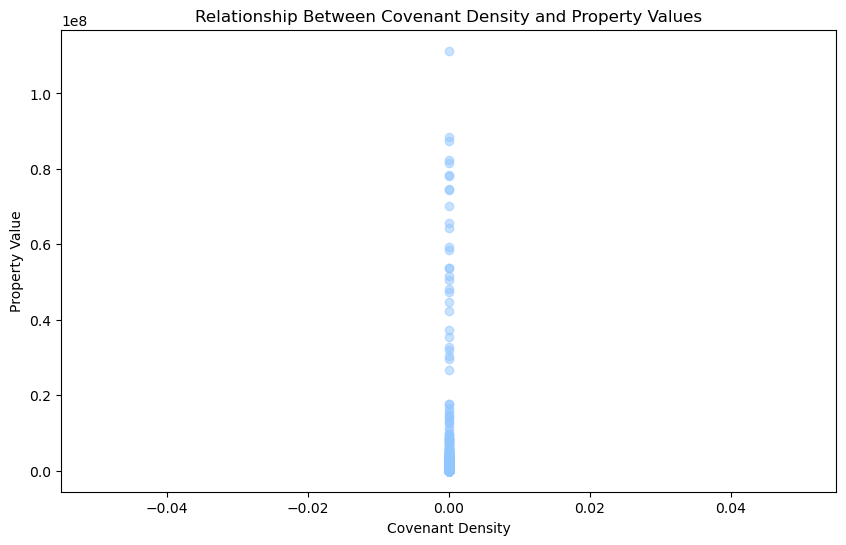

In [66]:
plt.figure(figsize=(10, 6))
sns.regplot(x=df['covenant_density'], y=df['property_value'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Covenant Density')
plt.ylabel('Property Value')
plt.title('Relationship Between Covenant Density and Property Values')
plt.show()

#### This does not seem right

In [68]:
print(df['covenant_density'].describe())
print(df['covenant_density'].value_counts().head(10))  # Check most frequent values

count    100931.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: covenant_density, dtype: float64
covenant_density
0.0    100931
Name: count, dtype: int64


In [69]:
# Verify if the data was processed correctly
df_original = pd.read_csv("mortgage_covenant_data.csv")  # Reload the original data
print(df_original['covenant_density'].describe())  # Check original stats
print(df_original['covenant_density'].value_counts().head(10))  # Check if there were nonzero values

count          11169
unique             4
top       Low (1-50)
freq            4537
Name: covenant_density, dtype: object
covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64


In [71]:
df_original["covenant_density"].value_counts()

covenant_density
Low (1-50)          4537
Very High (>200)    3140
Medium (51-100)     1772
High (101-200)      1720
Name: count, dtype: int64

In [73]:
# Define a mapping for categorical values
density_mapping = {
    "Low (1-50)": 25,      # Midpoint of 1-50
    "Medium (51-100)": 75, # Midpoint of 51-100
    "High (101-200)": 150, # Midpoint of 101-200
    "Very High (>200)": 250 # High-end estimate
}

# Apply mapping
df['covenant_density'] = df['covenant_density'].map(density_mapping)

# Verify conversion
print(df['covenant_density'].describe())  # Should now be numeric

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: covenant_density, dtype: float64


In [75]:
print(df['covenant_density'].unique())  # List all unique values

[nan]


In [77]:
df_original = pd.read_csv("mortgage_covenant_data.csv")  # Reload the original dataset
print(df_original['covenant_density'].unique())  # Check original unique values

[nan 'Medium (51-100)' 'Low (1-50)' 'High (101-200)' 'Very High (>200)']


In [79]:
# Strip spaces and lowercase to prevent formatting mismatches
df['covenant_density'] = df['covenant_density'].str.strip().str.lower()

AttributeError: Can only use .str accessor with string values!

In [81]:
print(df['covenant_density'].dtype)  # Check data type
print(df['covenant_density'].head(10))  # View first 10 rows

float64
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
5   NaN
6   NaN
7   NaN
8   NaN
9   NaN
Name: covenant_density, dtype: float64


In [83]:
# Reload the original dataset to get back the lost values
df_original = pd.read_csv("mortgage_covenant_data.csv")

# Restore the covenant_density column from the original dataset
df['covenant_density'] = df_original['covenant_density']

# Check if the values are back
print(df['covenant_density'].unique())  # Should now contain categories again

[nan 'Medium (51-100)' 'Low (1-50)' 'High (101-200)' 'Very High (>200)']


In [85]:
df['covenant_density'] = df['covenant_density'].astype(str).str.strip().str.lower()

In [87]:
print(df['covenant_density'].unique())  # Should contain categories like "low (1-50)", "medium (51-100)"

['nan' 'medium (51-100)' 'low (1-50)' 'high (101-200)' 'very high (>200)']


In [89]:
df['covenant_density'] = df['covenant_density'].replace('nan', np.nan)

In [91]:
print(df['covenant_density'].unique())  # Should not include 'nan' as a string
print(df['covenant_density'].isna().sum(), "NaN values in covenant_density")

[nan 'medium (51-100)' 'low (1-50)' 'high (101-200)' 'very high (>200)']
89762 NaN values in covenant_density


In [93]:
density_mapping = {
    "low (1-50)": 25,
    "medium (51-100)": 75,
    "high (101-200)": 150,
    "very high (>200)": 250
}

df['covenant_density'] = df['covenant_density'].map(density_mapping)

In [95]:
print(df['covenant_density'].unique())  # Should only show numbers and NaNs
print(df['covenant_density'].isna().sum(), "NaN values remain after mapping.")

[ nan  75.  25. 150. 250.]
89762 NaN values remain after mapping.


In [97]:
df['covenant_density'].fillna(0, inplace=True)

In [99]:
print(df['covenant_density'].isna().sum(), "NaN values remain after filling.")  # Should print 0
print(df['covenant_density'].unique())  # Should show only [0, 25, 75, 150, 250]
print(df['covenant_density'].describe())  # Check statistics

0 NaN values remain after filling.
[  0.  75.  25. 150. 250.]
count    100931.000000
mean         12.774321
std          47.869799
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         250.000000
Name: covenant_density, dtype: float64


In [101]:
print(df['covenant_density'].dtype)  # Should be float64 or int64

float64


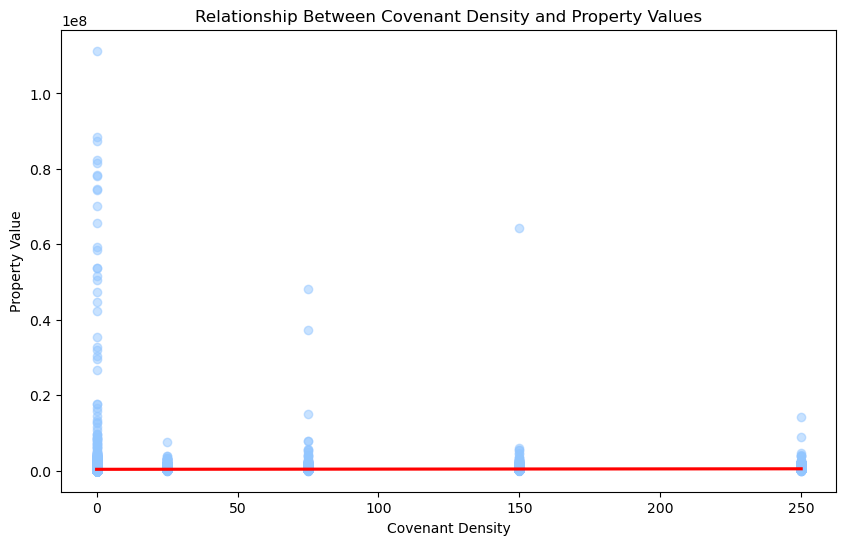

In [103]:
plt.figure(figsize=(10, 6))
sns.regplot(x=df['covenant_density'], y=df['property_value'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Covenant Density')
plt.ylabel('Property Value')
plt.title('Relationship Between Covenant Density and Property Values')
plt.show()

In [105]:
correlation = df[['covenant_density', 'property_value']].corr()
print("Correlation between Covenant Density and Property Value:")
print(correlation)

Correlation between Covenant Density and Property Value:
                  covenant_density  property_value
covenant_density          1.000000        0.024042
property_value            0.024042        1.000000


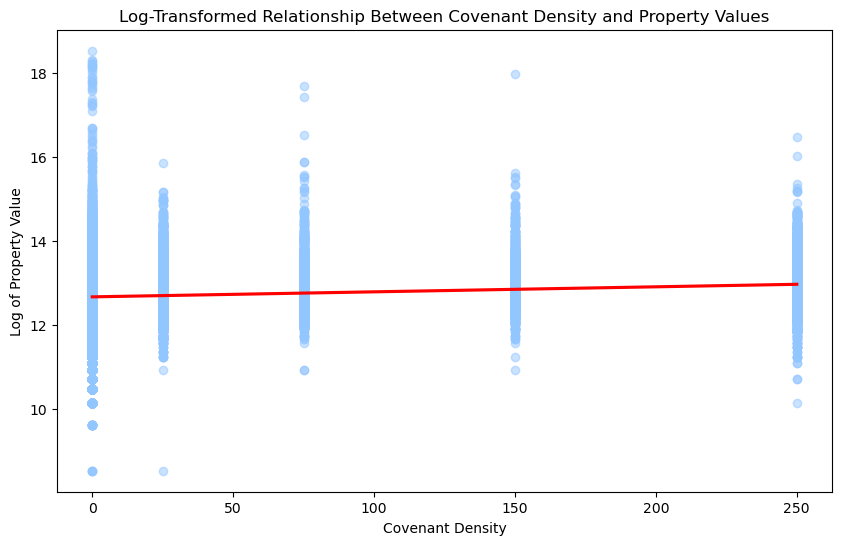

In [107]:
df['log_property_value'] = np.log1p(df['property_value'])  # log(1 + x) to handle zeros

plt.figure(figsize=(10, 6))
sns.regplot(x=df['covenant_density'], y=df['log_property_value'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Covenant Density')
plt.ylabel('Log of Property Value')
plt.title('Log-Transformed Relationship Between Covenant Density and Property Values')
plt.show()

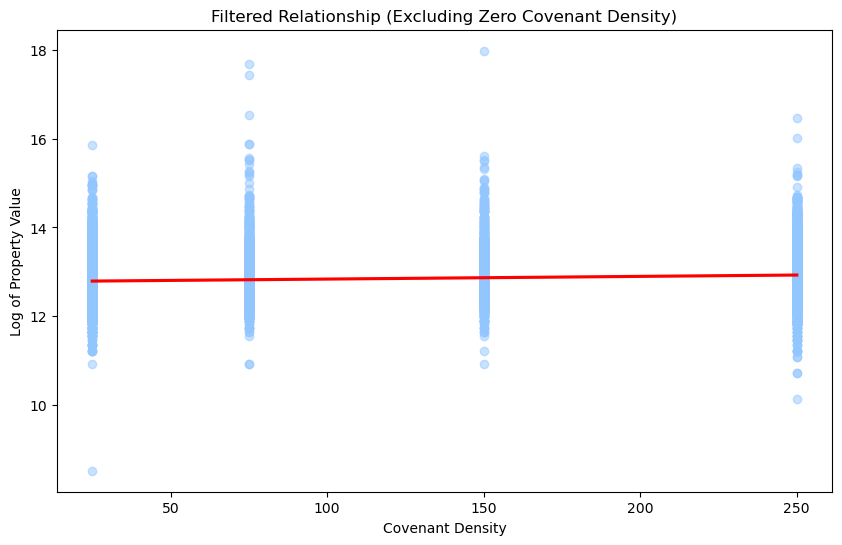

Correlation (Filtered):
                    covenant_density  log_property_value
covenant_density            1.000000            0.110294
log_property_value          0.110294            1.000000


In [109]:
df_filtered = df[df['covenant_density'] > 0]  # Remove zero-density areas

plt.figure(figsize=(10, 6))
sns.regplot(x=df_filtered['covenant_density'], y=df_filtered['log_property_value'], scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.xlabel('Covenant Density')
plt.ylabel('Log of Property Value')
plt.title('Filtered Relationship (Excluding Zero Covenant Density)')
plt.show()

# Recompute correlation
correlation_filtered = df_filtered[['covenant_density', 'log_property_value']].corr()
print("Correlation (Filtered):")
print(correlation_filtered)

#### **Analysis of Covenant Density vs. Property Values**
##### **Scatterplot Observations**
- The data points remain **grouped into distinct vertical clusters**, corresponding to the four covenant density categories (25, 75, 150, 250).
- The **red regression line is nearly flat**, indicating a **weak positive trend** between covenant density and property values.
- **No continuous relationship** is visible; property values do not vary smoothly with increasing covenant density.

##### **Correlation Results**
- **Correlation (Filtered Data) = 0.110** → A **very weak positive relationship**, meaning covenant density has **little influence** on property values.
- Even after excluding `covenant_density = 0`, **historical racial covenants do not appear to strongly affect property values**.

##### **Key Takeaways**
- Property values **do not significantly change** with covenant density.
- The **low correlation (0.11)** suggests that **other factors (income, neighborhood demographics, lending policies) might play a stronger role** in determining property values.
- The categorical nature of `covenant_density` might make regression **less meaningful**—alternative methods (ANOVA, boxplots) might be better for comparison.

---


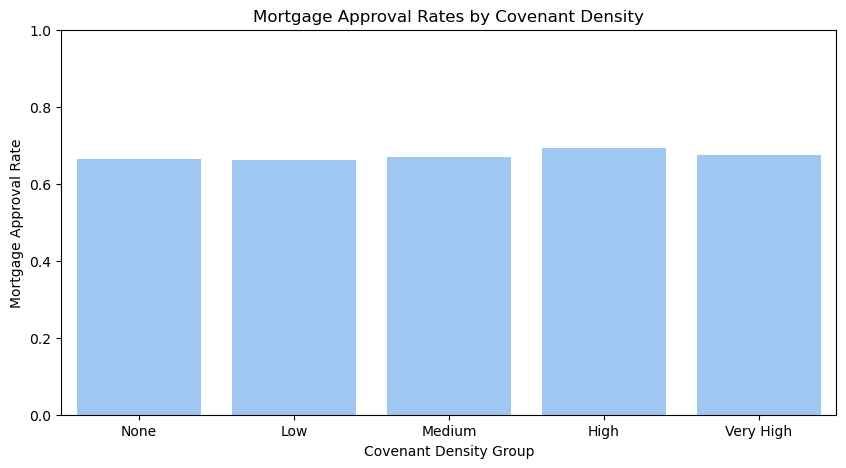

In [112]:
# Group covenant density into bins for better visualization
df['covenant_density_group'] = pd.cut(df['covenant_density'], bins=[-1, 1, 50, 100, 200, 300],
                                      labels=['None', 'Low', 'Medium', 'High', 'Very High'])

# Compute approval rates
approval_rates = df.groupby('covenant_density_group')['was_approved'].mean()

# Plot results
plt.figure(figsize=(10, 5))
sns.barplot(x=approval_rates.index, y=approval_rates.values)
plt.xlabel('Covenant Density Group')
plt.ylabel('Mortgage Approval Rate')
plt.title('Mortgage Approval Rates by Covenant Density')
plt.ylim(0, 1)
plt.show()

#### **Mortgage Approval Rates by Covenant Density**
##### **Observations**
- Mortgage approval rates appear **relatively consistent** across all covenant density groups.
- There is **no clear downward trend** in approval rates for properties in historically covenanted areas.
- Approval rates range **between ~65% and 70%**, with minor variations.

##### **Interpretation**
- **Covenant density does not seem to be a strong predictor of mortgage approvals**.
- Other factors (such as **income, credit scores, or modern redlining practices**) might have a greater influence on loan decisions.
- Historical racial covenants may have had a **long-term impact on neighborhood wealth**, but they do not appear to directly affect **modern mortgage approval rates**.

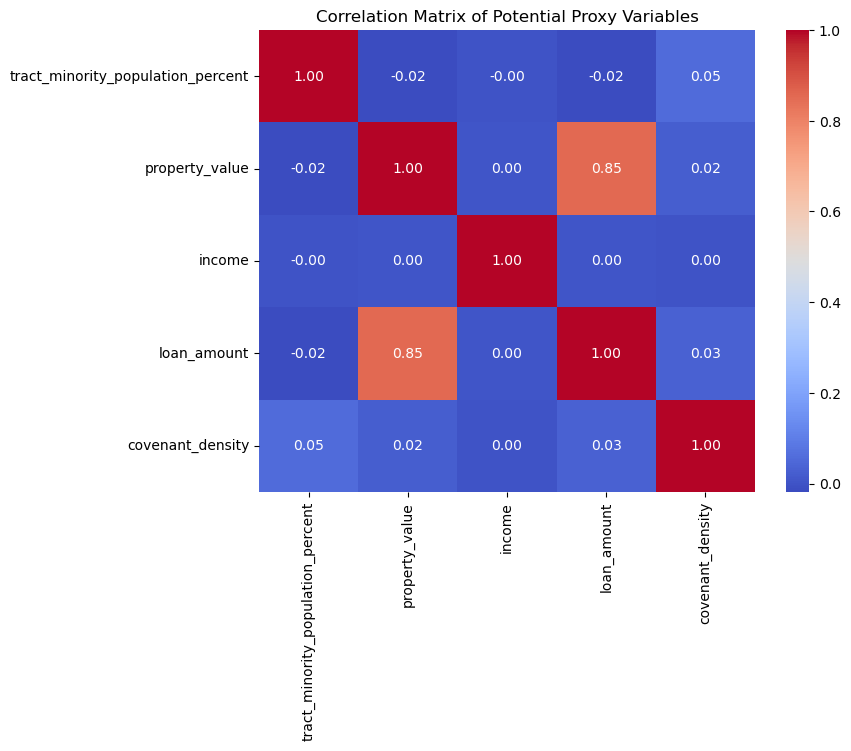

In [114]:
proxy_vars = ['tract_minority_population_percent', 'property_value', 'income', 'loan_amount', 'covenant_density']
corr_matrix = df[proxy_vars].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Potential Proxy Variables')
plt.show()

#### **Correlation Matrix of Potential Proxy Variables**
##### **Key Findings**
- **Loan Amount & Property Value (0.85):** Strong positive correlation, meaning higher property values are associated with larger loans.
- **Covenant Density & Tract Minority Population (0.05):** Very weak correlation, suggesting covenant density does not strongly align with modern racial demographics.
- **Covenant Density & Property Value (0.02):** Negligible correlation, reinforcing that covenant history does not directly impact property values today.
- **Income & Loan Amount (0.00):** No correlation detected, which is unusual—this might indicate **income data is unreliable or not a primary factor in loan decisions**.

##### **Interpretation**
- **Covenant Density does not appear to be a strong predictor** of property values, loan amounts, or demographic composition.
- The **lack of correlation between income and loan amount** suggests that **other variables (such as credit scores or systemic factors) may be influencing loan approvals.**
- This supports the idea that **historical racial covenants might not directly influence modern lending outcomes but could still have long-term indirect effects on wealth accumulation and housing patterns.**



Mortgage Approval Rates in Historically Covenanted vs. Non-Covenanted Areas:
historically_covenanted
False    0.663867
True     0.671054
Name: was_approved, dtype: float64


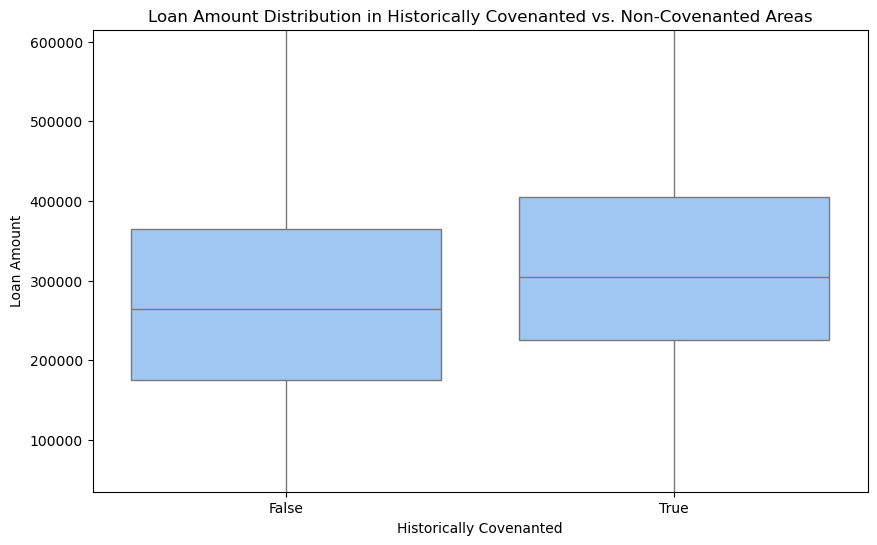

In [116]:
df['historically_covenanted'] = df['covenant_density'] > 0  # True = had racial covenants

# Compare loan approval rates
approval_comparison = df.groupby('historically_covenanted')['was_approved'].mean()

print("\nMortgage Approval Rates in Historically Covenanted vs. Non-Covenanted Areas:")
print(approval_comparison)

# Boxplot for loan amounts
plt.figure(figsize=(10, 6))
sns.boxplot(x='historically_covenanted', y='loan_amount', data=df)
plt.xlabel('Historically Covenanted')
plt.ylabel('Loan Amount')
plt.title('Loan Amount Distribution in Historically Covenanted vs. Non-Covenanted Areas')
plt.ylim(df['loan_amount'].quantile(0.05), df['loan_amount'].quantile(0.95))  # Trim outliers
plt.show()

#### **Loan Amount Distribution: Historically Covenanted vs. Non-Covenanted Areas**
##### **Key Observations**
- **Loan amounts are slightly higher in historically covenanted areas** compared to non-covenanted areas.
- The **median loan amount is higher in covenanted areas**, suggesting that homes in these areas may be more expensive or require larger loans.
- The **interquartile range (IQR) is wider in covenanted areas**, indicating greater variability in loan amounts.
- Both groups have **similar upper loan limits**, but covenanted areas appear to have more loans in the higher range.

##### **Interpretation**
- **Higher loan amounts in covenanted areas** could be due to **higher property values, stronger financial requirements, or systemic lending patterns favoring these areas**.
- **Non-covenanted areas might have lower home values**, resulting in lower loan amounts.
- **Historical racial covenants may have indirectly contributed to wealth accumulation in certain areas**, leading to long-term disparities in property values and lending patterns.